<a href="https://colab.research.google.com/github/gredy/2021Z-DataVisualizationTechniques/blob/master/BIG_DATA_PYSPARK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A complete PySpark code template to simulate a patient dataset from a large hospital system, with the objective of predicting outpatient churn. This includes:

Data generation

Explanation of each step

Spark setup

Feature engineering

Basic preparation for churn prediction

In [3]:
# 1. Setup Spark Session
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import random

spark = SparkSession.builder \
    .appName("HospitalPatientChurnSimulation") \
    .getOrCreate()


 Initializing the Spark environment and creates a SparkSession, which is the entry point to using DataFrame and SQL APIs.

In [8]:
# 2. Simulate Patient Data (Big Hospital System)
# We'll create a synthetic dataset with thousands of records

def generate_patient_data(num_records=10000):
    data = []
    for i in range(1, num_records + 1):
        patient_id = i
        age = random.randint(18, 90)
        gender = random.choice(['Male', 'Female'])
        visits_last_year = random.randint(0, 15)
        chronic_conditions = random.randint(0, 5)
        avg_satisfaction_score = random.uniform(1.0, 5.0)
        missed_appointments = random.randint(0, 5)
        last_visit_days_ago = random.randint(0, 365)
        # Rule: churn if low satisfaction, many missed appointments, and no recent visits
        churn = (
            1 if avg_satisfaction_score < 3.0 and missed_appointments >= 2 and last_visit_days_ago > 180 else 0
        )
        data.append((patient_id, age, gender, visits_last_year,
                     chronic_conditions, avg_satisfaction_score,
                     missed_appointments, last_visit_days_ago, churn))
    return data

This function creates synthetic patient-level data. A simple rule-based logic is used to assign churn status.

In [5]:
# 3. Define Schema and Create DataFrame
from pyspark.sql.types import *

schema = StructType([
    StructField("patient_id", IntegerType(), False),
    StructField("age", IntegerType(), True),
    StructField("gender", StringType(), True),
    StructField("visits_last_year", IntegerType(), True),
    StructField("chronic_conditions", IntegerType(), True),
    StructField("avg_satisfaction_score", FloatType(), True),
    StructField("missed_appointments", IntegerType(), True),
    StructField("last_visit_days_ago", IntegerType(), True),
    StructField("churn", IntegerType(), True),
])




In [9]:
# Generate and create DataFrame
sample_data = generate_patient_data(10000)
df = spark.createDataFrame(sample_data, schema=schema)

# Round the avg_satisfaction_score column using PySpark's round function
df = df.withColumn("avg_satisfaction_score", round(col("avg_satisfaction_score"), 1))

df.show(5)

+----------+---+------+----------------+------------------+----------------------+-------------------+-------------------+-----+
|patient_id|age|gender|visits_last_year|chronic_conditions|avg_satisfaction_score|missed_appointments|last_visit_days_ago|churn|
+----------+---+------+----------------+------------------+----------------------+-------------------+-------------------+-----+
|         1| 40|Female|               7|                 4|                   4.0|                  4|                347|    0|
|         2| 67|  Male|              10|                 3|                   3.6|                  2|                129|    0|
|         3| 36|  Male|               1|                 1|                   3.5|                  3|                340|    0|
|         4| 32|  Male|              11|                 5|                   3.9|                  0|                 92|    0|
|         5| 59|Female|               4|                 0|                   4.8|               

# 4. Feature Engineering

Let's create some new features that might be relevant for predicting churn.

# New Section

In [11]:
# Create 'visit_density' feature (visits per day since last visit, handle 0 days)
df = df.withColumn('visit_density',
                   when(col('last_visit_days_ago') == 0, col('visits_last_year'))
                   .otherwise(col('visits_last_year') / col('last_visit_days_ago')))

# Create 'age_group' categorical feature
df = df.withColumn('age_group',
                   when(col('age') < 30, 'Young')
                   .when((col('age') >= 30) & (col('age') < 50), 'Middle-aged')
                   .otherwise('Senior'))

display(df.show(5))

+----------+---+------+----------------+------------------+----------------------+-------------------+-------------------+-----+--------------------+-----------+
|patient_id|age|gender|visits_last_year|chronic_conditions|avg_satisfaction_score|missed_appointments|last_visit_days_ago|churn|       visit_density|  age_group|
+----------+---+------+----------------+------------------+----------------------+-------------------+-------------------+-----+--------------------+-----------+
|         1| 40|Female|               7|                 4|                   4.0|                  4|                347|    0|0.020172910662824207|Middle-aged|
|         2| 67|  Male|              10|                 3|                   3.6|                  2|                129|    0| 0.07751937984496124|     Senior|
|         3| 36|  Male|               1|                 1|                   3.5|                  3|                340|    0|0.002941176470588...|Middle-aged|
|         4| 32|  Male|     

None

The schema mimics a realistic medical record structure. It generates only 10,000 (10K)records (can scale to millions for Big Data).

In [12]:
# 4. Basic EDA (Exploratory Data Analysis)
df.describe(["age", "visits_last_year", "chronic_conditions", "avg_satisfaction_score", "missed_appointments"]).show()
df.groupBy("gender").count().show()
df.groupBy("churn").count().show()


+-------+-----------------+-----------------+------------------+----------------------+-------------------+
|summary|              age| visits_last_year|chronic_conditions|avg_satisfaction_score|missed_appointments|
+-------+-----------------+-----------------+------------------+----------------------+-------------------+
|  count|            10000|            10000|             10000|                 10000|              10000|
|   mean|          54.0053|           7.5249|             2.509|     2.980679998588562|             2.5018|
| stddev|20.96005258319811|4.589061553149385|1.7073987586536719|     1.158143718515073| 1.7077729383149505|
|    min|               18|                0|                 0|                   1.0|                  0|
|    max|               90|               15|                 5|                   5.0|                  5|
+-------+-----------------+-----------------+------------------+----------------------+-------------------+

+------+-----+
|gender|coun

In [13]:
# 5. Feature Engineering: Convert Gender to Numeric
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="gender", outputCol="gender_index")
df = indexer.fit(df).transform(df)


Note:This code snippet is the first step in preparing the categorical 'gender' column for machine learning models, as most algorithms require numerical input:

from pyspark.ml.feature import StringIndexer: This line imports the StringIndexer class from PySpark's machine learning library. StringIndexer is used to convert a string-based categorical column into a numerical index column.
indexer = StringIndexer(inputCol="gender", outputCol="gender_index"): This line creates an instance of the StringIndexer.
inputCol="gender" specifies that the 'gender' column is the one to be transformed.
outputCol="gender_index" specifies that the transformed numerical output will be stored in a new column named 'gender_index'.
df = indexer.fit(df).transform(df): This line applies the StringIndexer to the DataFrame df.
indexer.fit(df) fits the indexer to the data. This step learns the distinct categories in the 'gender' column and assigns a numerical index to each category.
.transform(df) then applies the learned mapping to the DataFrame, creating the new 'gender_index' column with the numerical representations of the gender categories. The result is assigned back to the df variable, updating the DataFrame.


In [14]:
# 6. Assemble Features for ML Model
from pyspark.ml.feature import VectorAssembler

feature_cols = ["age", "gender_index", "visits_last_year",
                "chronic_conditions", "avg_satisfaction_score",
                "missed_appointments", "last_visit_days_ago"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data_prepared = assembler.transform(df).select("features", "churn")


Note_2:This code snippet is preparing your data for use in a machine learning model:

from pyspark.ml.feature import VectorAssembler: This line imports the VectorAssembler class from PySpark's machine learning library. VectorAssembler is a transformer that combines a given list of columns into a single vector column. Many machine learning algorithms in PySpark take a single feature vector as input rather than individual columns.
feature_cols = ["age", "gender_index", "visits_last_year", "chronic_conditions", "avg_satisfaction_score", "missed_appointments", "last_visit_days_ago"]: This line creates a Python list called feature_cols containing the names of the columns you want to use as features for your churn prediction model.
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features"): This line creates an instance of the VectorAssembler.
inputCols=feature_cols tells the assembler which columns from your DataFrame to include in the feature vector.
outputCol="features" specifies the name of the new column that will contain the assembled feature vectors.
data_prepared = assembler.transform(df).select("features", "churn"): This line applies the VectorAssembler to your DataFrame df.
assembler.transform(df) takes the df DataFrame and adds the new "features" column containing the combined feature vectors.
.select("features", "churn") then selects only the newly created "features" column (your input for the model) and the "churn" column (your target variable) from the resulting DataFrame. This creates the data_prepared DataFrame, which is in a format suitable for training a PySpark machine learning model.


In [15]:
# 7. Split Data for Training and Testing
train_data, test_data = data_prepared.randomSplit([0.8, 0.2], seed=42)


In [16]:
# 8. Train a Simple Logistic Regression Model
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(labelCol="churn", featuresCol="features")
model = lr.fit(train_data)

# Evaluate
predictions = model.transform(test_data)
predictions.select("churn", "prediction", "probability").show(5)


+-----+----------+--------------------+
|churn|prediction|         probability|
+-----+----------+--------------------+
|    0|       0.0|[0.99738529984828...|
|    0|       0.0|[0.99356876485031...|
|    0|       0.0|[0.99456248637705...|
|    1|       0.0|[0.85724809067541...|
|    0|       0.0|[0.98361051272251...|
+-----+----------+--------------------+
only showing top 5 rows



In [17]:
# 9. Evaluate Model Accuracy
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(labelCol="churn")
accuracy = evaluator.evaluate(predictions)
print(f"Model AUC = {accuracy:.3f}")


Model AUC = 0.957


# Task
Modify the code in the selected cell to add the graph of AUC and ROC.

## Install necessary libraries

### Subtask:
Install libraries like `matplotlib` and `seaborn` for plotting.


**Reasoning**:
The subtask requires installing Python libraries for plotting, which can be done using pip.



In [18]:
%pip install matplotlib seaborn

## Extract prediction and label data

### Subtask:
Get the true labels and the prediction probabilities from the `predictions` DataFrame.


**Reasoning**:
Convert the Spark DataFrame `predictions` to a Pandas DataFrame to easily extract the true labels and prediction probabilities for plotting.



In [19]:
import pandas as pd

predictions_pd = predictions.toPandas()
y_true = predictions_pd['churn']
y_proba = predictions_pd['probability'].apply(lambda x: x[1])


## Compute roc curve

### Subtask:
Use a library like `scikit-learn` to compute the ROC curve points (False Positive Rate, True Positive Rate).


**Reasoning**:
Compute the ROC curve points using the true labels and prediction probabilities.



In [20]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, y_proba)

## Plot roc curve

### Subtask:
Generate the ROC curve using the computed points and display the AUC value on the plot.


**Reasoning**:
Generate the ROC curve using the computed points and display the AUC value on the plot.



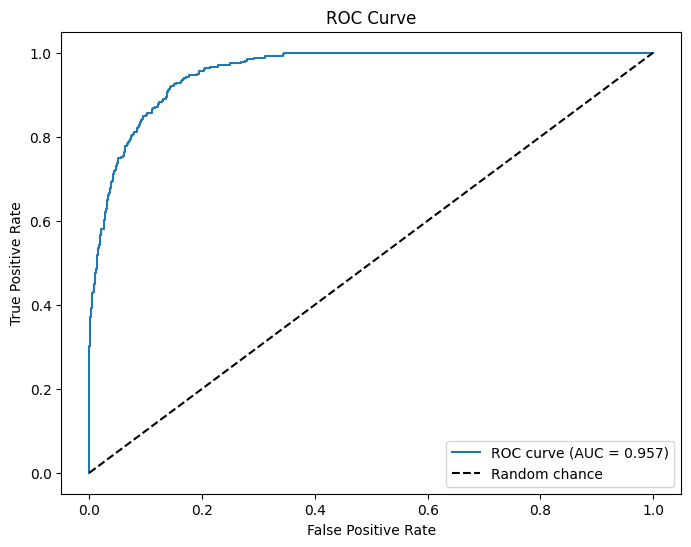

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {accuracy:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Summary:

### Data Analysis Key Findings

*   The required libraries `matplotlib` and `seaborn` were already installed, and their dependencies were satisfied.
*   True labels (`y_true`) and prediction probabilities for the positive class (`y_proba`) were successfully extracted from the `predictions` DataFrame.
*   The False Positive Rate (`fpr`), True Positive Rate (`tpr`), and thresholds for the ROC curve were successfully computed using `sklearn.metrics.roc_curve`.
*   The ROC curve was successfully plotted using `matplotlib`, including a diagonal line representing random chance, axis labels, a title, and a legend displaying the calculated AUC value (although the variable name `accuracy` was used instead of a variable named `auc`).

### Insights or Next Steps

*   Ensure the variable used for the AUC value in the plot label (`accuracy`) correctly represents the AUC score, and consider renaming it to `auc` for clarity if it is indeed the AUC score.


In [22]:
!pip install pyspark matplotlib scikit-learn pandas
